Aula de linha de regressão

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

importando dataset iris do conjunto de datasets salvos no sklearn

In [27]:
#df = pd.read_csv('iris.csv',sep=',')essa eh a forma manual
iris = datasets.load_iris()

criando subplot para testar a distribuição dos elementos 

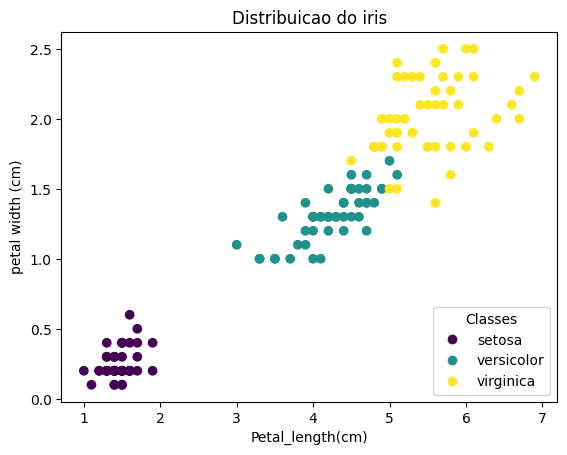

In [28]:
fig, ax= plt.subplots()
scatter = ax.scatter(iris.data[:,2],iris.data[:,3], c=iris.target)
ax.set_title('Distribuicao do iris')
ax.set_xlabel('Petal_length(cm)')
#ax.set_ylabel('Petal_width(com)')#opcao tradicional
ax.set_ylabel(iris.feature_names[3])#outra opcao
ax.legend(scatter.legend_elements()[0],iris.target_names,loc="lower right",title="Classes")
plt.show()

regressão linear

In [29]:
X = iris.data[:,2].reshape(-1,1)#petal_length
y = iris.data[:,3]#petal_width
especie = iris.target

fazendo train teste split tradicional com elementos de especie

In [30]:
X_treino,X_teste,y_treino,y_teste,especie_treino,especie_teste=train_test_split(X,y,especie,test_size=0.3,random_state=40)

treinando modelo

In [31]:
regressao = linear_model.LinearRegression()
regressao.fit(X_treino, y_treino)
y_pred = regressao.predict(X_teste)

Gerando resulltado

In [32]:
r2=r2_score(y_teste,y_pred)
mse= mean_squared_error(y_teste,y_pred)
rmse = mse ** 0.5
print(r2,mse,rmse)

0.9412602234764752 0.03529491875692053 0.18786941942988095


criando mascara

In [33]:
setosa=especie_teste == 0
versicolor = especie_teste == 1
virginica = especie_teste == 2

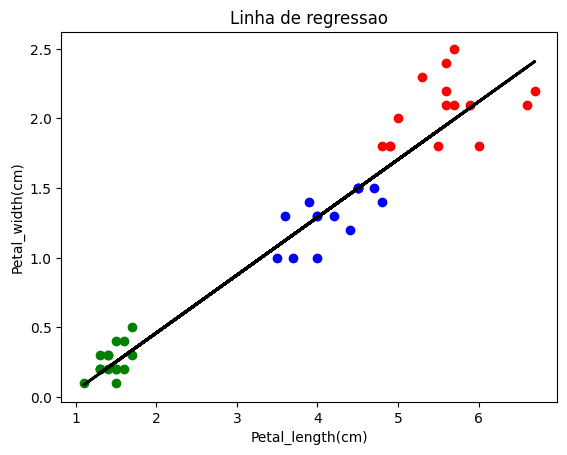

In [34]:
plt.scatter(X_teste[setosa], y_teste[setosa],color='green',label = 'setosa')
plt.scatter(X_teste[versicolor], y_teste[versicolor],color='blue',label = 'versicolor')
plt.scatter(X_teste[virginica], y_teste[virginica],color='red',label = 'virginica')
plt.plot(X_teste,y_pred, color='black',linewidth=2,label='Linha de regressao')
plt.xlabel('Petal_length(cm)')
plt.ylabel('Petal_width(cm)')
plt.title('Linha de regressao')
plt.show()